In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 

In [2]:
df= pd.read_csv(r"E:\practise class sheet\Bd_Rw_D pvl _dataset.csv")
 

In [6]:
df

,patient_id,visit_date,district,facility_type,age,gender,diagnosis,treatment_given,comorbidity_present,medication_adherence,monthly_treatment_cost_bdt,outcome,month
0,PT-100041,2023-01-01,Chattogram,Upazila Health Complex,55,Male,Hypertension,Losartan,No,High,538,Improved,2023-01
1,PT-100744,2023-01-01,Mymensingh,Upazila Health Complex,63,Female,Type 2 Diabetes Mellitus,Metformin,No,High,1699,Stable/Ongoing,2023-01
2,PT-102736,2023-01-01,Rangpur,Private Clinic,44,Male,Hypertension,Hydrochlorothiazide,No,Low,1048,Improved,2023-01
3,PT-103940,2023-01-01,Dhaka,Private Clinic,47,Female,Chronic Kidney Disease (CKD),Calcium Carbonate,Yes,Low,2066,Referred to Specialist,2023-01
4,PT-101135,2023-01-01,Comilla,Private Clinic,58,Female,Type 2 Diabetes Mellitus,Gliclazide,Yes,Moderate,452,Referred to Specialist,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,PT-101643,2024-12-30,Bogura,Private Hospital,53,Male,Chronic Kidney Disease (CKD),Calcium Carbonate,Yes,High,1624,Referred to Specialist,2024-12
4996,PT-102109,2024-12-30,Chattogram,NGO Health Center,42,Male,Hypertension,Telmisartan,No,High,612,Referred to Specialist,2024-12
4997,PT-103531,2024-12-30,Dhaka,NGO Health Center,48,Male,Type 2 Diabetes Mellitus,Empagliflozin,No,Moderate,2067,Improved,2024-12
4998,PT-104841,2024-12-30,Comilla,NGO Health Center,35,Female,Dengue Fever,Paracetamol,No,High,2024,Improved,2024-12


In [8]:
df["visit_date"] = pd.to_datetime(df["visit_date"])
df["month"] = df["visit_date"].dt.to_period("M")

In [7]:
print("Total rows:", len(df))

Total rows: 5000


In [9]:
print(df.head())

  patient_id visit_date    district           facility_type  age  gender  \
0  PT-100041 2023-01-01  Chattogram  Upazila Health Complex   55    Male   
1  PT-100744 2023-01-01  Mymensingh  Upazila Health Complex   63  Female   
2  PT-102736 2023-01-01     Rangpur          Private Clinic   44    Male   
3  PT-103940 2023-01-01       Dhaka          Private Clinic   47  Female   
4  PT-101135 2023-01-01     Comilla          Private Clinic   58  Female   

                      diagnosis      treatment_given comorbidity_present  \
0                  Hypertension             Losartan                  No   
1      Type 2 Diabetes Mellitus            Metformin                  No   
2                  Hypertension  Hydrochlorothiazide                  No   
3  Chronic Kidney Disease (CKD)    Calcium Carbonate                 Yes   
4      Type 2 Diabetes Mellitus           Gliclazide                 Yes   

  medication_adherence  monthly_treatment_cost_bdt                 outcome  \
0       

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   patient_id                  5000 non-null   object        
 1   visit_date                  5000 non-null   datetime64[ns]
 2   district                    5000 non-null   object        
 3   facility_type               5000 non-null   object        
 4   age                         5000 non-null   int64         
 5   gender                      5000 non-null   object        
 6   diagnosis                   5000 non-null   object        
 7   treatment_given             5000 non-null   object        
 8   comorbidity_present         5000 non-null   object        
 9   medication_adherence        5000 non-null   object        
 10  monthly_treatment_cost_bdt  5000 non-null   int64         
 11  outcome                     5000 non-null   object      

In [15]:
df.columns

Index(['patient_id', 'visit_date', 'district', 'facility_type', 'age',
       'gender', 'diagnosis', 'treatment_given', 'comorbidity_present',
       'medication_adherence', 'monthly_treatment_cost_bdt', 'outcome',
       'month'],
      dtype='object')

In [16]:
sns.set_style("whitegrid")

In [22]:
#Disease Prevalence by District
disease_by_district = df.groupby("district")["diagnosis"].value_counts()

In [23]:
print("\n--- Disease Prevalence by District ---")
print(disease_by_district)


--- Disease Prevalence by District ---
district  diagnosis                   
Barishal  Hypertension                    38
          Type 2 Diabetes Mellitus        38
          Dengue Fever                    19
          Ischemic Heart Disease          19
          Bronchial Asthma                18
                                          ..
Sylhet    Chronic Kidney Disease (CKD)    12
          Rheumatoid Arthritis             9
          Chronic Liver Disease            8
          Major Depressive Disorder        7
          Stroke                           5
Name: count, Length: 180, dtype: int64


In [21]:
#District wise total case count (overall prevalence)
district_total = df["district"].value_counts()

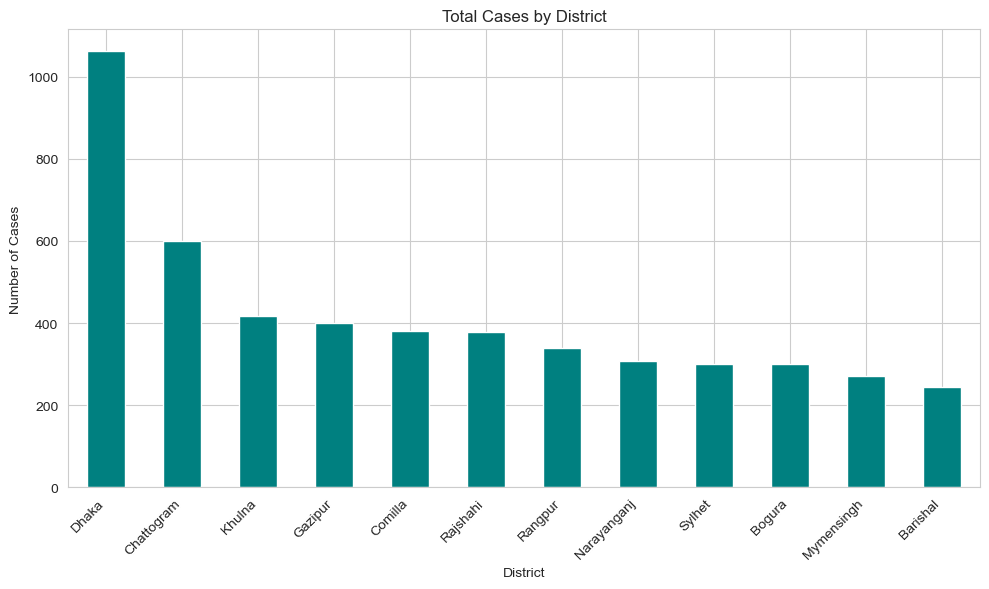

In [35]:
plt.figure(figsize=(10, 6))
district_total.plot(kind="bar", color="teal")
plt.title("Total Cases by District")
plt.ylabel("Number of Cases")
plt.xlabel("District")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step1_district_prevalence.png")
plt.show()     


In [26]:
# Top disease per district by hitmap view
top_disease_district = (
    df.groupby(["district", "diagnosis"]).size().reset_index(name="count")
)

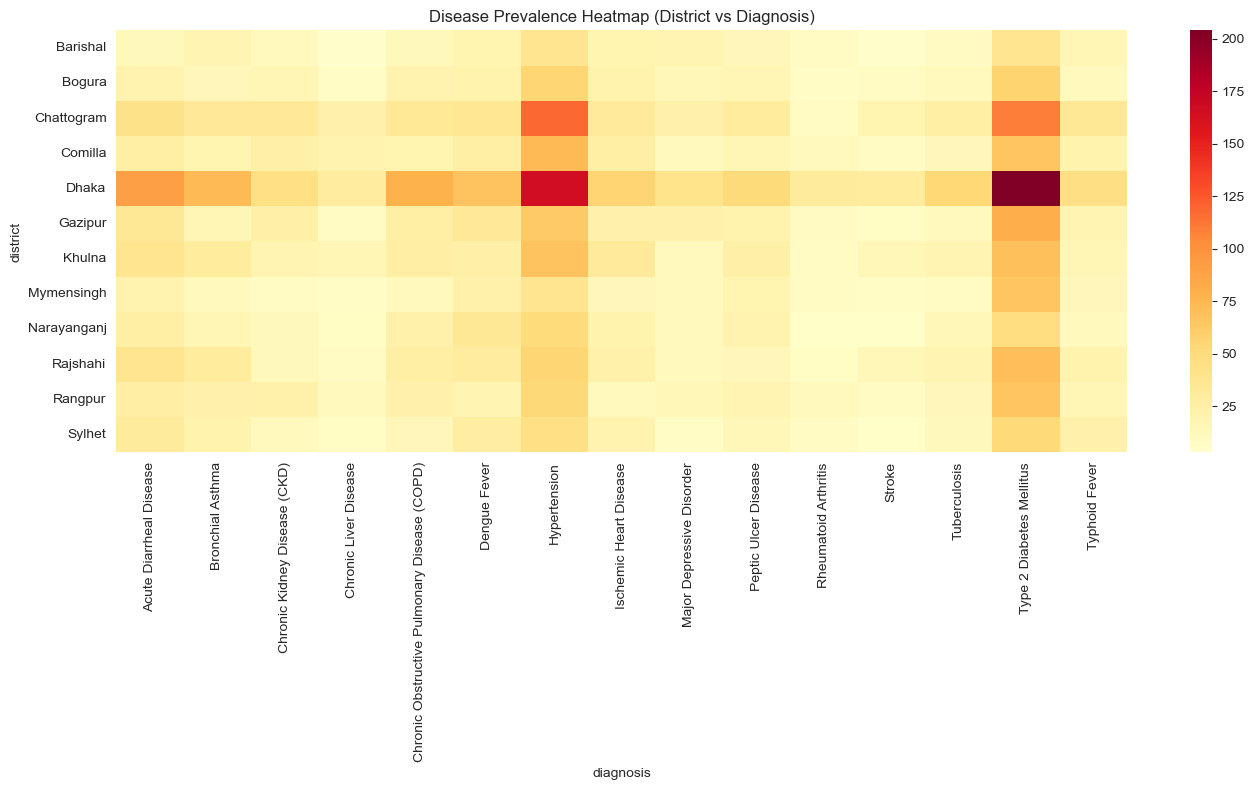

In [59]:

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_dd, cmap="YlOrRd", annot=False)
plt.title("Disease Prevalence Heatmap (District vs Diagnosis)")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step1_district_disease_heatmap.png")
plt.show()

In [36]:
#TREATMENT GIVEN BY PER DISEASE
treatment_pattern = (
    df.groupby("diagnosis")["treatment_given"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("percent")
    .reset_index()
)
print("\n--- Treatment Pattern per Disease (%) ---")
print(treatment_pattern)
 


--- Treatment Pattern per Disease (%) ---
                                       diagnosis  \
0                        Acute Diarrheal Disease   
1                        Acute Diarrheal Disease   
2                        Acute Diarrheal Disease   
3                        Acute Diarrheal Disease   
4                               Bronchial Asthma   
5                               Bronchial Asthma   
6                               Bronchial Asthma   
7                   Chronic Kidney Disease (CKD)   
8                   Chronic Kidney Disease (CKD)   
9                   Chronic Kidney Disease (CKD)   
10                  Chronic Kidney Disease (CKD)   
11                         Chronic Liver Disease   
12                         Chronic Liver Disease   
13                         Chronic Liver Disease   
14  Chronic Obstructive Pulmonary Disease (COPD)   
15  Chronic Obstructive Pulmonary Disease (COPD)   
16  Chronic Obstructive Pulmonary Disease (COPD)   
17  Chronic Obstructi

In [37]:
disease_name = "Type 2 Diabetes Mellitus"
sub = df[df["diagnosis"] == disease_name]["treatment_given"].value_counts()

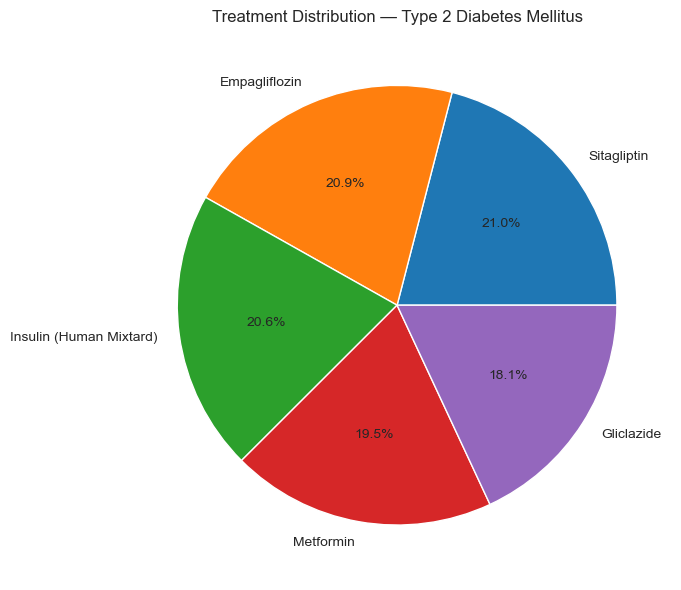

In [41]:
plt.figure(figsize=(8, 6))
sub.plot(kind="pie", autopct="%1.1f%%")
plt.title(f"Treatment Distribution — {disease_name}")
plt.ylabel("")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step2_treatment_pattern_example.png")
plt.show()



In [42]:
#Age Ke Group e ভাগ Kora (bins)
bins = [0, 12, 18, 35, 50, 65, 100]
labels = ["0-12", "13-18", "19-35", "36-50", "51-65", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

In [43]:
age_gender_disease = df.groupby(["age_group", "gender"])["diagnosis"].value_counts()
print("\n--- Age/Gender wise Disease Distribution ---")
print(age_gender_disease)


--- Age/Gender wise Disease Distribution ---
age_group  gender  diagnosis              
0-12       Female  Dengue Fever               32
                   Acute Diarrheal Disease    24
                   Typhoid Fever              16
                   Bronchial Asthma           15
                   Peptic Ulcer Disease       10
                                              ..
65+        Male    Dengue Fever                2
                   Tuberculosis                2
                   Typhoid Fever               2
                   Acute Diarrheal Disease     1
                   Peptic Ulcer Disease        0
Name: count, Length: 180, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_12276\52834334.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_disease = df.groupby(["age_group", "gender"])["diagnosis"].value_counts()


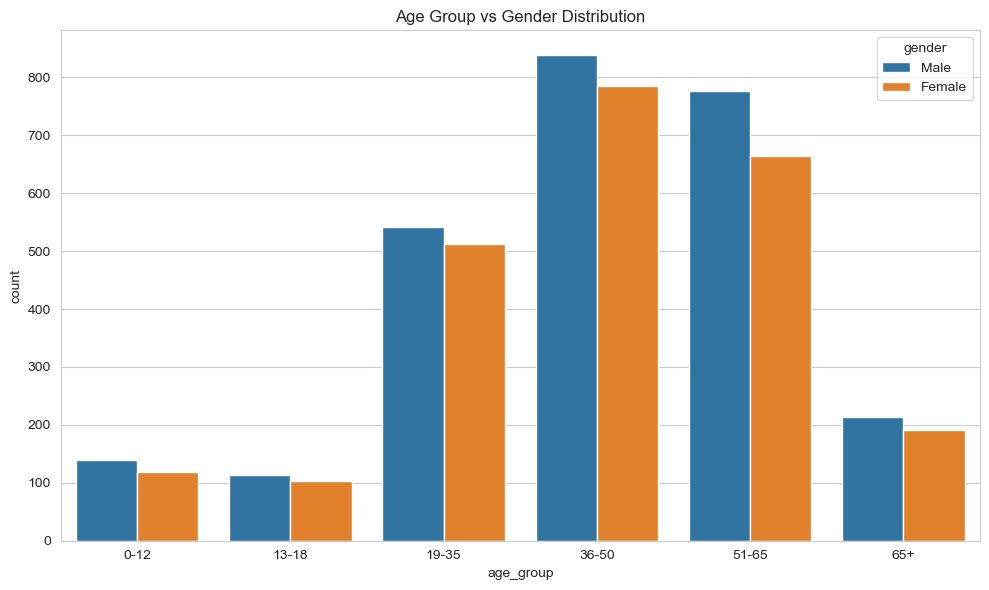

In [45]:
# Age / Gender wise Disease Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="age_group", hue="gender")
plt.title("Age Group vs Gender Distribution")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step3_age_gender_distribution.png")
plt.show()


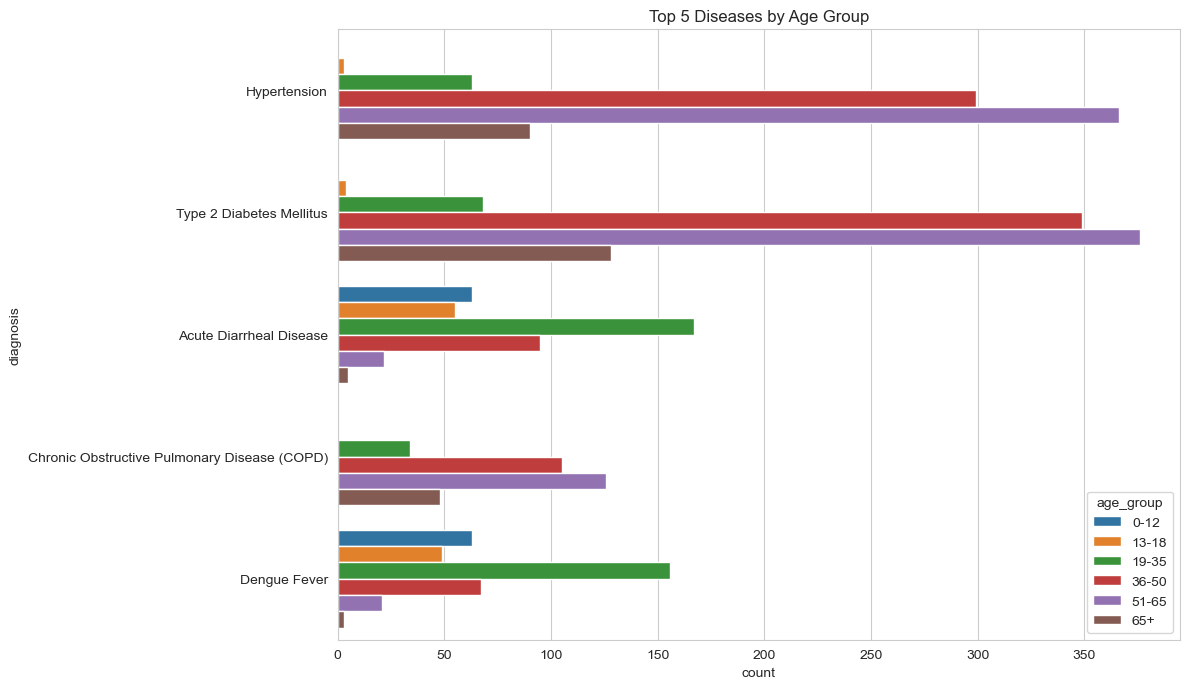

In [47]:
#Distribution by Age and disease and patint treatment
plt.figure(figsize=(12, 7))
top5_diseases = df["diagnosis"].value_counts().head(5).index
sns.countplot(data=df[df["diagnosis"].isin(top5_diseases)], y="diagnosis", hue="age_group")
plt.title("Top 5 Diseases by Age Group")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step3_top_diseases_by_age.png")
plt.show()
plt.close()


--- Adherence vs Outcome (%) ---
   medication_adherence                 outcome  percent
0                  High                Improved     45.0
1                  High          Stable/Ongoing     28.2
2                  High  Referred to Specialist     12.3
3                  High              Readmitted      7.0
4                  High       Lost to Follow-up      5.6
5                  High                Deceased      1.9
6                   Low                Improved     41.4
7                   Low          Stable/Ongoing     31.4
8                   Low  Referred to Specialist     11.9
9                   Low              Readmitted      7.1
10                  Low       Lost to Follow-up      6.0
11                  Low                Deceased      2.2
12             Moderate                Improved     45.0
13             Moderate          Stable/Ongoing     28.8
14             Moderate  Referred to Specialist     11.8
15             Moderate              Readmitted      6

<Figure size 1000x600 with 0 Axes>

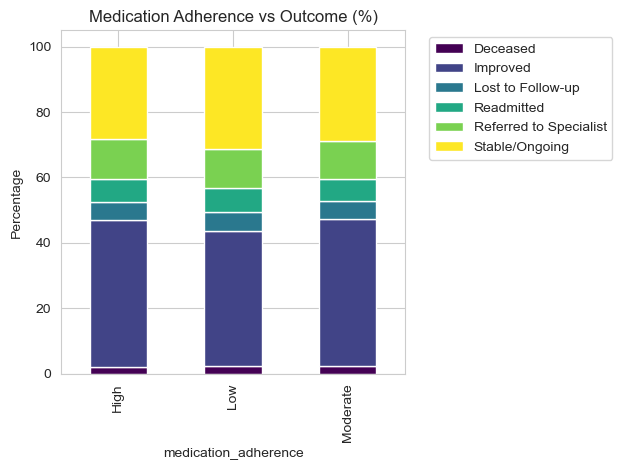

In [49]:
# Adherence vs Outcome Relationship view
adherence_outcome = (
    df.groupby("medication_adherence")["outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("percent")
    .reset_index()
)
print("\n--- Adherence vs Outcome (%) ---")
print(adherence_outcome)
 
cross_tab = pd.crosstab(df["medication_adherence"], df["outcome"], normalize="index") * 100
 
plt.figure(figsize=(10, 6))
cross_tab.plot(kind="bar", stacked=True, colormap="viridis")
plt.title("Medication Adherence vs Outcome (%)")
plt.ylabel("Percentage")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step4_adherence_vs_outcome.png")
plt.show()



--- Avg Cost by Disease ---
                                                mean  median      sum
diagnosis                                                            
Rheumatoid Arthritis                          1353.4  1335.0   174587
Chronic Obstructive Pulmonary Disease (COPD)  1281.7  1224.0   401176
Dengue Fever                                  1263.3  1213.0   453524
Tuberculosis                                  1246.3  1202.0   265472
Major Depressive Disorder                     1226.2  1164.0   240344
Type 2 Diabetes Mellitus                      1222.2  1183.0  1130494
Chronic Kidney Disease (CKD)                  1206.7  1102.5   289607
Stroke                                        1205.1  1187.0   162693
Bronchial Asthma                              1200.8  1182.0   366240
Acute Diarrheal Disease                       1200.5  1141.0   488587
Hypertension                                  1198.2  1168.0   983740
Peptic Ulcer Disease                          1186.1  1183.0 

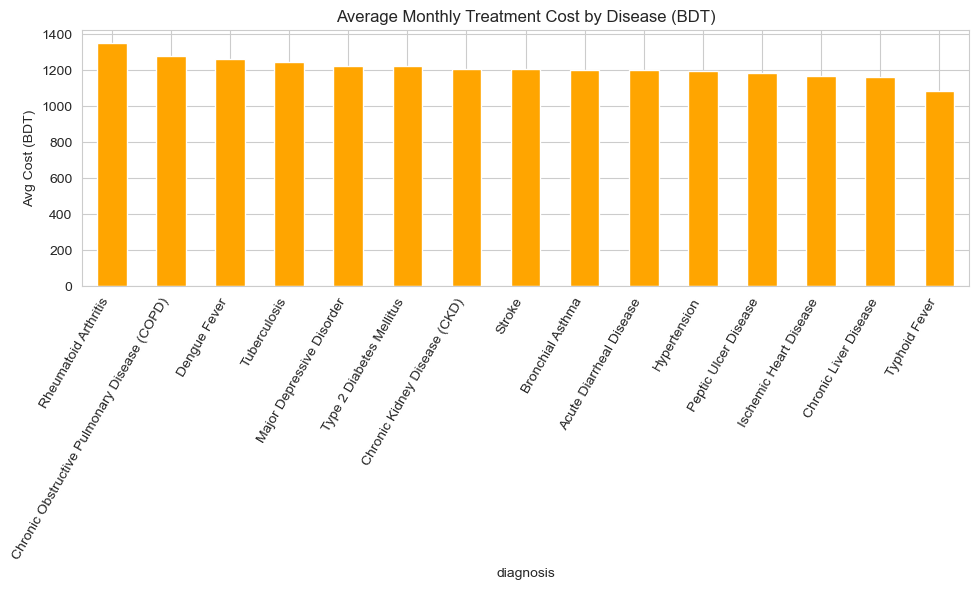

In [51]:
# Cost Analysis by Disease & Facility Type view....
cost_by_disease = df.groupby("diagnosis")["monthly_treatment_cost_bdt"].agg(["mean", "median", "sum"]).round(1)
cost_by_facility = df.groupby("facility_type")["monthly_treatment_cost_bdt"].agg(["mean", "median", "sum"]).round(1)
 
print("\n--- Avg Cost by Disease ---")
print(cost_by_disease.sort_values("mean", ascending=False))
print("\n--- Avg Cost by Facility Type ---")
print(cost_by_facility.sort_values("mean", ascending=False))
 
plt.figure(figsize=(10, 6))
cost_by_disease["mean"].sort_values(ascending=False).plot(kind="bar", color="orange")
plt.title("Average Monthly Treatment Cost by Disease (BDT)")
plt.ylabel("Avg Cost (BDT)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step5_cost_by_disease.png")
plt.show()

 

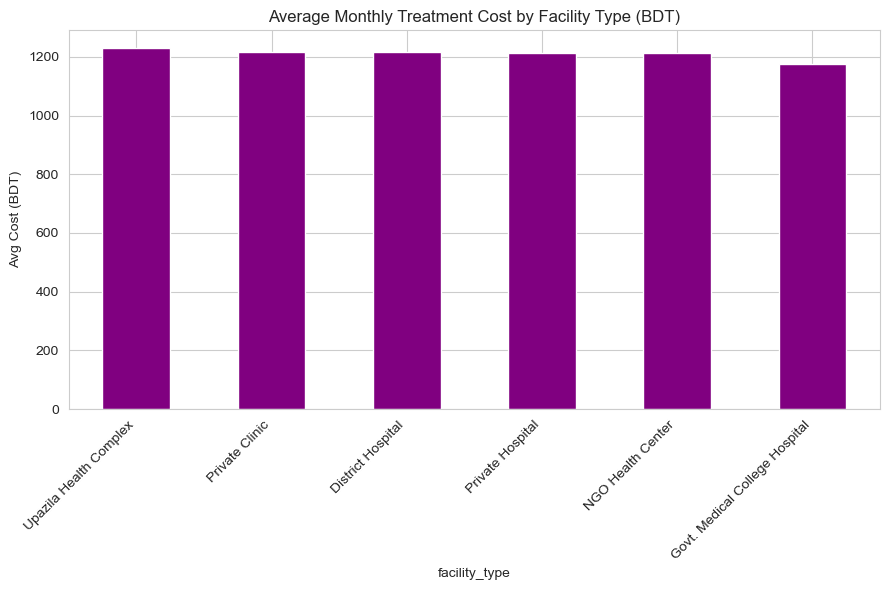

In [52]:
plt.figure(figsize=(9, 6))
cost_by_facility["mean"].sort_values(ascending=False).plot(kind="bar", color="purple")
plt.title("Average Monthly Treatment Cost by Facility Type (BDT)")
plt.ylabel("Avg Cost (BDT)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step5_cost_by_facility.png")
plt.show()


In [53]:
#Time Trend — Monthly Disease Burden  Month wise diseases increses view
monthly_trend = df.groupby(["month", "diagnosis"]).size().reset_index(name="count")
monthly_total = df.groupby("month").size()
 
print("\n--- Monthly Total Case Trend ---")
print(monthly_total)


--- Monthly Total Case Trend ---
month
2023-01    216
2023-02    197
2023-03    248
2023-04    218
2023-05    195
2023-06    199
2023-07    221
2023-08    217
2023-09    247
2023-10    185
2023-11    213
2023-12    199
2024-01    224
2024-02    207
2024-03    213
2024-04    203
2024-05    218
2024-06    207
2024-07    208
2024-08    200
2024-09    178
2024-10    220
2024-11    164
2024-12    203
Freq: M, dtype: int64


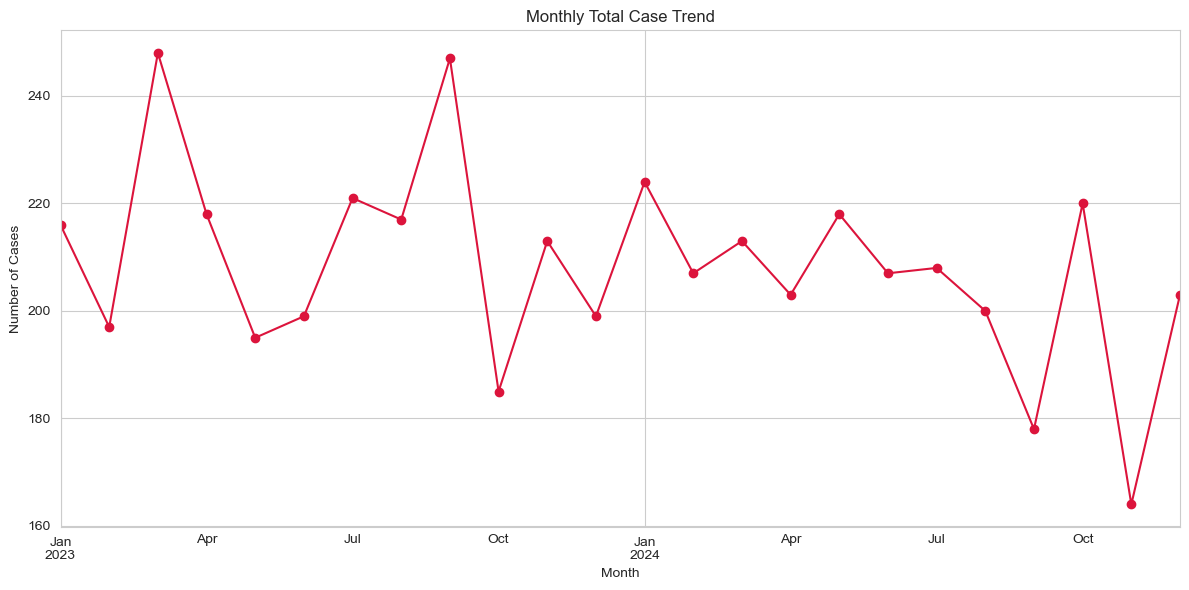

In [57]:
#Specific disease-er monthly trend (jemon: Dengue Fever)
plt.figure(figsize=(12, 6))
monthly_total.plot(kind="line", marker="o", color="crimson")
plt.title("Monthly Total Case Trend")
plt.ylabel("Number of Cases")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step6_monthly_total_trend.png")
plt.show()


In [55]:
disease_trend = df[df["diagnosis"] == "Dengue Fever"].groupby("month").size()

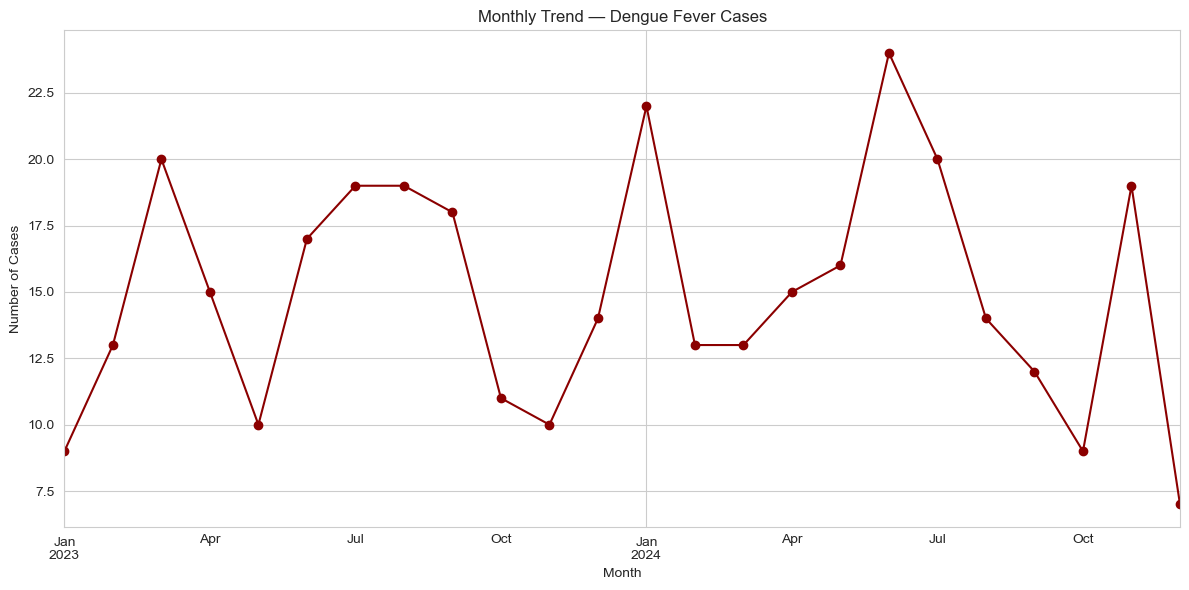

In [56]:
plt.figure(figsize=(12, 6))
disease_trend.plot(kind="line", marker="o", color="darkred")
plt.title("Monthly Trend — Dengue Fever Cases")
plt.ylabel("Number of Cases")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig(r"E:\practise class sheet\step6_dengue_monthly_trend.png")
plt.show()


In [58]:
print("\nAll charts saved as PNG files in the current folder.")


All charts saved as PNG files in the current folder.
